### Read-in downloaded data

In [1]:
import os
import logging
import time

import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_recommenders as tfrs

In [2]:
def get_broadcaster_data_set(train_ds):
    broadcasters = train_ds.cache().map(lambda x: x["broadcaster"], num_parallel_calls=tf.data.AUTOTUNE, deterministic=False)
    broadcasters_ds = tf.data.Dataset.from_tensor_slices(
        np.unique(list(broadcasters.as_numpy_iterator())))
    return broadcasters_ds


def get_list(training_data, key):
    return training_data.batch(1_000_000).map(lambda x: x[key], num_parallel_calls=tf.data.AUTOTUNE, deterministic=False)


def get_unique_list(data):
    return np.unique(np.concatenate(list(data)))


def load_data_file_cold(file, stats):
    print('loading file:' + file)
    training_df = pd.read_csv(
        file,
        skiprows=[0],
        names=["viewer",
               "broadcaster",
               "viewer_age",
               "viewer_gender",
               "viewer_longitude",
               "viewer_latitude",
               "viewer_lang",
               "viewer_country",
               "broadcaster_age",
               "broadcaster_gender",
               "broadcaster_longitude",
               "broadcaster_latitude",
               "broadcaster_lang",
               "broadcaster_country",
               "duration", 
               "viewer_network", 
               "broadcaster_network", 
               "viewer_lat_long_cluster",
               "rank"], 
        dtype={
            'viewer': np.unicode,
            'broadcaster': np.unicode,
            'viewer_age': np.single,
            'viewer_gender': np.unicode,
            'viewer_longitude': np.single,
            'viewer_latitude': np.single,
            'viewer_lang': np.unicode,
            'viewer_country': np.unicode,
            'broadcaster_age': np.single,
            'broadcaster_longitude': np.single,
            'broadcaster_latitude': np.single,
            'broadcaster_lang': np.unicode,
            'broadcaster_country': np.unicode,
            'viewer_network': np.unicode,
            'broadcaster_network': np.unicode,
            'viewer_lat_long_cluster': np.unicode,
            'rank': np.unicode,
        })

    values = {
        'viewer': 'unknown',
        'broadcaster': 'unknown',
        'viewer_age': 30,
        'viewer_gender': 'unknown',
        'viewer_longitude': 0,
        'viewer_latitude': 0,
        'viewer_lang': 'unknown',
        'viewer_country': 'unknown',
        'broadcaster_age': 30,
        'broadcaster_longitude': 0,
        'broadcaster_latitude': 0,
        'broadcaster_lang': 'unknown',
        'broadcaster_country': 'unknown',
        'duration': 0,
        'viewer_network': 'unknown',
        'broadcaster_network': 'unknown',
        'viewer_lat_long_cluster': '0',
        'rank': '1'
    }
    training_df.fillna(value=values, inplace=True)
    print(training_df.head(10))
    print(training_df.iloc[-10:])
    # stats.send_stats('data-size', len(training_df.index))
    samples = training_df.sample(frac=.1)
    return samples


def load_training_data_cold(file, stats):
    ratings_df = load_data_file_cold(file, stats)
    print('creating data set')
    training_ds = (
        tf.data.Dataset.from_tensor_slices(
            ({
                "viewer": tf.cast(
                    ratings_df['viewer'].values,
                    tf.string),
                "viewer_gender": tf.cast(
                    ratings_df['viewer_gender'].values,
                    tf.string),
                "viewer_lang": tf.cast(
                    ratings_df['viewer_lang'].values,
                    tf.string),
                "viewer_country": tf.cast(
                    ratings_df['viewer_country'].values,
                    tf.string),
                "viewer_age": tf.cast(
                    ratings_df['viewer_age'].values,
                    tf.int32),
                "viewer_longitude": tf.cast(
                    ratings_df['viewer_longitude'].values,
                    tf.float16),
                "viewer_latitude": tf.cast(
                    ratings_df['viewer_latitude'].values,
                    tf.float16),
                "broadcaster": tf.cast(
                    ratings_df['broadcaster'].values,
                    tf.string),
                "viewer_network": tf.cast(
                    ratings_df['viewer_network'].values,
                    tf.string),
                "broadcaster_network": tf.cast(
                    ratings_df['broadcaster_network'].values,
                    tf.string),
                "viewer_lat_long_cluster": tf.cast(
                    ratings_df['viewer_lat_long_cluster'].values,
                    tf.string),
            })))

    return training_ds

def prepare_training_data_cold(train_ds):
    print('prepare_training_data')
    training_ds = train_ds.cache().map(lambda x: {
        "broadcaster": x["broadcaster"],
        "viewer": x["viewer"],
        "viewer_gender": x["viewer_gender"],
        "viewer_lang": x["viewer_lang"],
        "viewer_country": x["viewer_country"],
        "viewer_age": x["viewer_age"],
        "viewer_longitude": x["viewer_longitude"],
        "viewer_latitude": x["viewer_latitude"],
        "viewer_network": x["viewer_network"],
        "broadcaster_network": x["broadcaster_network"],
        "viewer_lat_long_cluster": x["viewer_lat_long_cluster"],
    }, num_parallel_calls=tf.data.AUTOTUNE,
       deterministic=False)

    print('done prepare_training_data')
    return training_ds


def current_milli_time():
    return round(time.time() * 1000)

### Read-in data

In [4]:
print("training_process")
start_time = current_milli_time()
broadcaster_embedding_dimension = 32
viewer_embedding_dimension = 32

batch_size = 1638
learning_rate = 0.05
epochs = 10
top_k = 199

training_process


In [5]:
!ls csv

0e9cd673-8e06-4810-b370-8b9930ee312a.csv
2021-09-22.csv
2021-09-23.csv
2021-10-01.csv
2021-10-05.csv
2021-10-07.csv
2021-10-28-cleaned.csv
2021-10-28.csv
2021-11-05.csv
2021-11-22.csv
50c39121-3de2-4b6b-b134-bb51732c1d6f.csv
a3d86f3b-eb45-4641-b05d-30dff7423e6b.csv
df_score.csv
df_score_518.csv
res.csv
viewer_lat_long_centroids.csv


In [6]:
import pandas as pd

In [8]:
training_dataset = load_training_data_cold("csv/2021-11-22.csv", "")
train = prepare_training_data_cold(training_dataset)
broadcasters_data_set = get_broadcaster_data_set(training_dataset)

loading file:csv/2021-11-22.csv
                                            viewer  \
0  45 85 43 06 5f e1 cc 1d ad 2b 95 55 59 7f e1 4b   
1  9d 41 ac 98 8b 54 6f 78 50 d4 db 0b d8 fd 80 df   
2  12 02 e1 9b a4 23 af d1 c5 c1 aa d0 05 fa 51 cf   
3  c8 d8 15 6e cf 5b 09 e3 d6 f3 16 9e 9c 05 40 d8   
4  9d 41 ac 98 8b 54 6f 78 50 d4 db 0b d8 fd 80 df   
5  88 3a 7b 32 40 44 eb 66 03 93 e2 93 3b ba 21 14   
6  d4 e6 67 39 64 40 e5 59 93 2b c2 b8 50 de 26 03   
7  e5 98 43 d1 4e 13 aa 68 c7 ba a4 9e 5f 5c 3b 3e   
8  09 10 8b df fb 46 9f 7e c2 93 97 5d 8c 05 72 2c   
9  c8 d8 15 6e cf 5b 09 e3 d6 f3 16 9e 9c 05 40 d8   

                                       broadcaster  viewer_age viewer_gender  \
0  f2 4c 75 ee 7b 35 16 8e db 23 23 62 95 5f e0 d5        26.0          male   
1  88 10 58 1a cf b1 b8 8a 86 92 2e bf 6d 29 6d 30        29.0          male   
2  fd 87 40 b6 5b 39 1f 24 80 bd 9c 37 06 d0 27 74        30.0          male   
3  10 f0 80 30 38 2f 14 08 4c 96 56 c7 cb 49 66 76   

creating data set
prepare_training_data
done prepare_training_data


In [9]:
print("get lists")

user_genders = get_list(train, "viewer_gender")
user_langs = get_list(train, "viewer_lang")
user_countries = get_list(train, "viewer_country")
user_networks = get_list(train, "viewer_network")

viewer_age = get_list(train, "viewer_age")
viewer_longitude = get_list(train, "viewer_longitude")
viewer_latitude = get_list(train, "viewer_latitude")

broadcaster_ids = get_list(train, "broadcaster")

data_set_size = len(broadcaster_ids)

get lists


In [10]:
print("get_unique_list")
unique_broadcasters = get_unique_list(broadcaster_ids)
unique_user_genders = get_unique_list(user_genders)
unique_user_langs = get_unique_list(user_langs)
unique_user_countries = get_unique_list(user_countries)
unique_user_networks = get_unique_list(user_networks)
print(unique_broadcasters)

get_unique_list
[b'00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a'
 b'00 00 57 d7 03 6d 73 83 3e 58 ec 06 39 87 4a 5f'
 b'00 00 a4 8e cc 01 52 81 dd 45 4e f3 51 f8 f6 b0' ...
 b'ff fe a2 32 2c 3a 25 17 e7 3d 7b ab 39 1e 2a 92'
 b'ff ff 89 02 d8 53 2a be da 73 75 98 fb 4a 03 83'
 b'ff ff d7 35 f3 a8 66 fd 21 7a 78 07 1d 15 0c 78']


In [11]:
 print("unique broadcasters: " + str(len(unique_broadcasters)))

unique broadcasters: 80091


In [12]:
class UserModel(tf.keras.Model) :

    def __init__(self, unique_genders, unique_langs, unique_countries, viewer_age, unique_networks, unique_clusters) :
        super().__init__()

        self.gender_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_genders, mask_token=None),
            tf.keras.layers.Embedding(len(unique_genders) + 1, 4),
        ])

        self.lang_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_langs, mask_token=None),
            tf.keras.layers.Embedding(len(unique_langs) + 1, 10),
        ])

        self.country_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_countries, mask_token=None),
            tf.keras.layers.Embedding(len(unique_countries) + 1, 10),
        ])

        self.network_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_networks, mask_token=None),
            tf.keras.layers.Embedding(len(unique_networks) + 1, 4),
        ])

        age_boundaries = np.array([18, 25, 30, 35, 40, 45, 50, 55, 60, 65, float("inf")])
        self.viewer_age_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.Discretization(age_boundaries.tolist()),
            tf.keras.layers.Embedding(len(age_boundaries), 2)
        ])
        
        self.viewer_lat_long_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_clusters, mask_token=None),
            tf.keras.layers.Embedding(len(unique_clusters) + 1, 2),
        ])


    def call(self, inputs) :
        return tf.concat([
            self.gender_embedding(inputs["viewer_gender"]),
            self.lang_embedding(inputs["viewer_lang"]),
            self.country_embedding(inputs["viewer_country"]),
            self.network_embedding(inputs["viewer_network"]),
            self.viewer_age_embedding(inputs["viewer_age"]),
            self.viewer_lat_long_embedding(inputs["viewer_lat_long_cluster"]),
        ], axis = 1)

In [13]:
user_clusters = get_list(train, "viewer_lat_long_cluster")

In [14]:
unique_user_clusters = get_unique_list(user_clusters)
print(unique_user_clusters)

[b'0' b'1' b'2' b'3' b'4' b'5' b'6' b'7']


In [15]:
user_model = UserModel(unique_user_genders, unique_user_langs, unique_user_countries, viewer_age, unique_user_networks, unique_user_clusters)

In [16]:
class BroadcasterModel(tf.keras.Model):

    def __init__(self, unique_broadcaster_titles, dims):
        super().__init__()

        self.broadcaster_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_broadcaster_titles, mask_token=None),
            tf.keras.layers.Embedding(len(unique_broadcaster_titles) + 1, dims)
        ])

    def call(self, broadcaster):
        return tf.concat([
            self.broadcaster_embedding(broadcaster),
        ], axis=1)

In [17]:
broadcaster_model = BroadcasterModel(
    unique_broadcasters,
    broadcaster_embedding_dimension)

In [18]:
metrics = tfrs.metrics.FactorizedTopK(
    candidates=broadcasters_data_set.batch(128).map(broadcaster_model)
)

task = tfrs.tasks.Retrieval(
    metrics=metrics
)

In [19]:
from typing import Dict, Text

class TwoTowers(tf.keras.Model):

    def __init__(self, broadcaster_model, user_model, task):
        super().__init__()
        self.broadcaster_model: tf.keras.Model = broadcaster_model
        self.embedding_model = user_model
        self.task: tf.keras.layers.Layer = task

    def train_step(self, features: Dict[Text, tf.Tensor]) -> tf.Tensor:

        # Set up a gradient tape to record gradients.
        with tf.GradientTape() as tape:

            # Loss computation.

            user_embeddings = self.embedding_model({
                "viewer_gender": features["viewer_gender"],
                "viewer_lang": features["viewer_lang"],
                "viewer_country": features["viewer_country"],
                "viewer_age": features["viewer_age"],
                "viewer_network": features["viewer_network"],
                "viewer_latitude": features["viewer_latitude"],
                "viewer_longitude": features["viewer_longitude"],
                "viewer_lat_long_cluster": features["viewer_lat_long_cluster"]
            })
            positive_broadcaster_embeddings = self.broadcaster_model(
                features["broadcaster"])
            loss = self.task(user_embeddings, positive_broadcaster_embeddings)

            # Handle regularization losses as well.
            regularization_loss = sum(self.losses)

            total_loss = loss + regularization_loss

        gradients = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(
            zip(gradients, self.trainable_variables))

        metrics = {metric.name: metric.result() for metric in self.metrics}
        metrics["loss"] = loss
        metrics["regularization_loss"] = regularization_loss
        metrics["total_loss"] = total_loss

        return metrics

    def test_step(self, features: Dict[Text, tf.Tensor]) -> tf.Tensor:

        # Loss computation.

        user_embeddings = self.embedding_model({
                "viewer_gender": features["viewer_gender"],
                "viewer_lang": features["viewer_lang"],
                "viewer_country": features["viewer_country"],
                "viewer_age": features["viewer_age"],
                "viewer_network": features["viewer_network"],
                "viewer_latitude": features["viewer_latitude"],
                "viewer_longitude": features["viewer_longitude"],
                "viewer_lat_long_cluster": features["viewer_lat_long_cluster"]
        })
        positive_broadcaster_embeddings = self.broadcaster_model(
            features["broadcaster"])
        loss = self.task(user_embeddings, positive_broadcaster_embeddings)

        # Handle regularization losses as well.
        regularization_loss = sum(self.losses)

        total_loss = loss + regularization_loss

        metrics = {metric.name: metric.result() for metric in self.metrics}
        metrics["loss"] = loss
        metrics["regularization_loss"] = regularization_loss
        metrics["total_loss"] = total_loss
        return metrics

In [20]:
model = TwoTowers(broadcaster_model, user_model, task)

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adagrad(
        learning_rate=learning_rate))

In [22]:
tf.random.set_seed(42)
shuffled = train.shuffle(100_000, seed=42, reshuffle_each_iteration=False)

train_p80 = shuffled.take(80_000)
test_p20 = shuffled.skip(80_000).take(20_000)

cached_train = train_p80.shuffle(100_000).batch(2048)
cached_test = test_p20.batch(2048).cache()

In [23]:
# model.fit(train_ds, epochs=epochs)
old_model_history = model.fit(
    cached_train,
    validation_data=cached_test,
    validation_freq=5,
    epochs=10,
    verbose=0)

Instructions for updating:
The `validate_indices` argument has no effect. Indices are always validated on CPU and never validated on GPU.


In [24]:
old_model_history.history

{'factorized_top_k/top_1_categorical_accuracy': [0.0002500000118743628,
  0.0010625000577419996,
  0.0014375000027939677,
  0.0019249999895691872,
  0.0024625000078231096,
  0.0026000000070780516,
  0.0030125000048428774,
  0.0033499998971819878,
  0.003375000087544322,
  0.004025000147521496],
 'factorized_top_k/top_5_categorical_accuracy': [0.0043875002302229404,
  0.008425000123679638,
  0.010649999603629112,
  0.013137499801814556,
  0.014449999667704105,
  0.01477499958127737,
  0.016975000500679016,
  0.019899999722838402,
  0.02267500013113022,
  0.024962499737739563],
 'factorized_top_k/top_10_categorical_accuracy': [0.008225000463426113,
  0.015824999660253525,
  0.019349999725818634,
  0.02437499910593033,
  0.024299999698996544,
  0.026225000619888306,
  0.03071250021457672,
  0.035349998623132706,
  0.04019999876618385,
  0.043162498623132706],
 'factorized_top_k/top_50_categorical_accuracy': [0.028737500309944153,
  0.05198749899864197,
  0.0653500035405159,
  0.0757125020

### New User Model with Holdout Layers  tf.keras.layers.Dropout(0.5),

In [25]:
class UserModel(tf.keras.Model) :

    def __init__(self, unique_genders, unique_langs, unique_countries, viewer_age, unique_networks, unique_clusters) :
        super().__init__()

        self.gender_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_genders, mask_token=None),
            tf.keras.layers.Embedding(len(unique_genders) + 1, 4),
        ])

        self.lang_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_langs, mask_token=None),
            tf.keras.layers.Embedding(len(unique_langs) + 1, 10),
        ])

        self.country_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_countries, mask_token=None),
            tf.keras.layers.Embedding(len(unique_countries) + 1, 10),
        ])

        self.network_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_networks, mask_token=None),
            tf.keras.layers.Embedding(len(unique_networks) + 1, 4),
        ])

        age_boundaries = np.array([18, 25, 30, 35, 40, 45, 50, 55, 60, 65, float("inf")])
        self.viewer_age_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.Discretization(age_boundaries.tolist()),
            tf.keras.layers.Embedding(len(age_boundaries), 2)
        ])
        
        self.viewer_lat_long_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_clusters, mask_token=None),
            tf.keras.layers.Embedding(len(unique_clusters) + 1, 2),
        ])


    def call(self, inputs) :
        return tf.concat([
            self.gender_embedding(inputs["viewer_gender"]),
            self.lang_embedding(inputs["viewer_lang"]),
            self.country_embedding(inputs["viewer_country"]),
            self.network_embedding(inputs["viewer_network"]),
            self.viewer_age_embedding(inputs["viewer_age"]),
            self.viewer_lat_long_embedding(inputs["viewer_lat_long_cluster"]),
        ], axis = 1)

In [26]:
user_clusters = get_list(train, "viewer_lat_long_cluster")

In [27]:
unique_user_clusters = get_unique_list(user_clusters)
print(unique_user_clusters)

[b'0' b'1' b'2' b'3' b'4' b'5' b'6' b'7']


In [28]:
user_model = UserModel(unique_user_genders, unique_user_langs, unique_user_countries, viewer_age, unique_user_networks, unique_user_clusters)

In [29]:
class BroadcasterModel(tf.keras.Model):

    def __init__(self, unique_broadcaster_titles, dims):
        super().__init__()

        self.broadcaster_embedding = tf.keras.Sequential([
            tf.keras.layers.experimental.preprocessing.StringLookup(
                vocabulary=unique_broadcaster_titles, mask_token=None),
            tf.keras.layers.Embedding(len(unique_broadcaster_titles) + 1, dims),
            tf.keras.layers.Dropout(0.5)
        ])

    def call(self, broadcaster):
        return tf.concat([
            self.broadcaster_embedding(broadcaster),
        ], axis=1)

In [30]:
broadcaster_model = BroadcasterModel(
    unique_broadcasters,
    broadcaster_embedding_dimension)

In [31]:
metrics = tfrs.metrics.FactorizedTopK(
    candidates=broadcasters_data_set.batch(128).map(broadcaster_model)
)

task = tfrs.tasks.Retrieval(
    metrics=metrics
)

In [32]:
from typing import Dict, Text

class TwoTowers(tf.keras.Model):

    def __init__(self, broadcaster_model, user_model, task):
        super().__init__()
        self.broadcaster_model: tf.keras.Model = broadcaster_model
        self.embedding_model = user_model
        self.task: tf.keras.layers.Layer = task

    def train_step(self, features: Dict[Text, tf.Tensor]) -> tf.Tensor:

        # Set up a gradient tape to record gradients.
        with tf.GradientTape() as tape:

            # Loss computation.

            user_embeddings = self.embedding_model({
                "viewer_gender": features["viewer_gender"],
                "viewer_lang": features["viewer_lang"],
                "viewer_country": features["viewer_country"],
                "viewer_age": features["viewer_age"],
                "viewer_network": features["viewer_network"],
                "viewer_latitude": features["viewer_latitude"],
                "viewer_longitude": features["viewer_longitude"],
                "viewer_lat_long_cluster": features["viewer_lat_long_cluster"]
            })
            positive_broadcaster_embeddings = self.broadcaster_model(
                features["broadcaster"])
            loss = self.task(user_embeddings, positive_broadcaster_embeddings)

            # Handle regularization losses as well.
            regularization_loss = sum(self.losses)

            total_loss = loss + regularization_loss

        gradients = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(
            zip(gradients, self.trainable_variables))

        metrics = {metric.name: metric.result() for metric in self.metrics}
        metrics["loss"] = loss
        metrics["regularization_loss"] = regularization_loss
        metrics["total_loss"] = total_loss

        return metrics

    def test_step(self, features: Dict[Text, tf.Tensor]) -> tf.Tensor:

        # Loss computation.

        user_embeddings = self.embedding_model({
                "viewer_gender": features["viewer_gender"],
                "viewer_lang": features["viewer_lang"],
                "viewer_country": features["viewer_country"],
                "viewer_age": features["viewer_age"],
                "viewer_network": features["viewer_network"],
                "viewer_latitude": features["viewer_latitude"],
                "viewer_longitude": features["viewer_longitude"],
                "viewer_lat_long_cluster": features["viewer_lat_long_cluster"]
        })
        positive_broadcaster_embeddings = self.broadcaster_model(
            features["broadcaster"])
        loss = self.task(user_embeddings, positive_broadcaster_embeddings)

        # Handle regularization losses as well.
        regularization_loss = sum(self.losses)

        total_loss = loss + regularization_loss

        metrics = {metric.name: metric.result() for metric in self.metrics}
        metrics["loss"] = loss
        metrics["regularization_loss"] = regularization_loss
        metrics["total_loss"] = total_loss
        return metrics

In [33]:
model = TwoTowers(broadcaster_model, user_model, task)

In [34]:
model.compile(
    optimizer=tf.keras.optimizers.Adagrad(
        learning_rate=learning_rate))

In [35]:
tf.random.set_seed(42)
shuffled = train.shuffle(100_000, seed=42, reshuffle_each_iteration=False)

train_p80 = shuffled.take(80_000)
test_p20 = shuffled.skip(80_000).take(20_000)

cached_train = train_p80.shuffle(100_000).batch(2048)
cached_test = test_p20.batch(2048).cache()

In [36]:
# model.fit(train_ds, epochs=epochs)
new_model_history = model.fit(
    cached_train,
    validation_data=cached_test,
    validation_freq=5,
    epochs=10,
    verbose=0)

In [37]:
new_model_history.history

{'factorized_top_k/top_1_categorical_accuracy': [0.00019999999494757503,
  0.001025000005029142,
  0.0013749999925494194,
  0.0018500000005587935,
  0.0021124999038875103,
  0.002512499922886491,
  0.0024874999653548002,
  0.0027749999426305294,
  0.0034749999176710844,
  0.0033875000663101673],
 'factorized_top_k/top_5_categorical_accuracy': [0.004000000189989805,
  0.0073124999180436134,
  0.009624999947845936,
  0.012187499552965164,
  0.012537499889731407,
  0.013362499885261059,
  0.015087500214576721,
  0.018050000071525574,
  0.019712500274181366,
  0.02163749933242798],
 'factorized_top_k/top_10_categorical_accuracy': [0.007499999832361937,
  0.013899999670684338,
  0.017662499099969864,
  0.022087499499320984,
  0.021974999457597733,
  0.02382499910891056,
  0.02707500010728836,
  0.03232499957084656,
  0.0351875014603138,
  0.03799999877810478],
 'factorized_top_k/top_50_categorical_accuracy': [0.026525000110268593,
  0.04806249961256981,
  0.0609624981880188,
  0.07077500224

In [38]:
%matplotlib inline
import matplotlib.pyplot as plt

In [39]:
num_validation_runs = len(new_model_history.history["factorized_top_k/top_100_categorical_accuracy"])

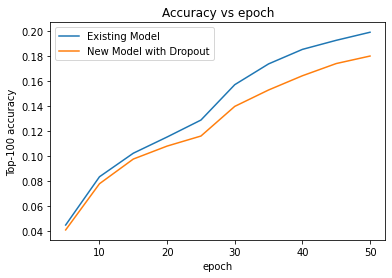

In [40]:
epochs = [(x + 1)* 5 for x in range(num_validation_runs)]

plt.plot(epochs, old_model_history.history["factorized_top_k/top_100_categorical_accuracy"], label="Existing Model")
plt.plot(epochs, new_model_history.history["factorized_top_k/top_100_categorical_accuracy"], label="New Model with Dropout")
plt.title("Accuracy vs epoch")
plt.xlabel("epoch")
plt.ylabel("Top-100 accuracy");
plt.legend()

In [41]:
accuracy = old_model_history.history["factorized_top_k/top_100_categorical_accuracy"][-1]
print(f"Top-100 accuracy: {accuracy:.4f}.")

Top-100 accuracy: 0.1989.


In [42]:
accuracy = new_model_history.history["factorized_top_k/top_100_categorical_accuracy"][-1]
print(f"Top-100 accuracy: {accuracy:.4f}.")

Top-100 accuracy: 0.1799.
